In [87]:
import json
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_classif

In [88]:
#  1. Load raw JSON

def load_subject(filepath, subject_id):
    with open(filepath, 'r') as f:
        records = json.load(f)

    sensor_data = [r for r in records if r['sensor'] not in ('Metadata', 'Tags')]

    sensor_names = set(r['sensor'] for r in sensor_data)
    dfs = {}
    for name in sensor_names:
        rows = [r for r in sensor_data if r['sensor'] == name]
        df = pd.DataFrame(rows)

        df['time'] = pd.to_numeric(df['time'])
        df['time'] = pd.to_datetime(df['time'], unit='ns')
        df = df.sort_values('time').reset_index(drop=True)

        df = df.drop(columns=['sensor', 'seconds_elapsed'], errors='ignore')

        for col in df.columns:
            if col != 'time':
                df[col] = pd.to_numeric(df[col], errors='coerce')

        df['subject'] = subject_id
        dfs[name] = df

    return dfs


subject1_dfs = load_subject(
    'subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json',
    subject_id=1
)
subject2_dfs = load_subject(
    'subject_2_minutes_25_typing_writing_drawing-2026-06-06_19-07-40.json',
    subject_id=2
)

 # 2. Merge subjects per sensor

all_sensors = set(subject1_dfs.keys()) | set(subject2_dfs.keys())

sensor_dfs = {}
for sensor in all_sensors:
    parts = []
    if sensor in subject1_dfs:
        parts.append(subject1_dfs[sensor])
    if sensor in subject2_dfs:
        parts.append(subject2_dfs[sensor])
    sensor_dfs[sensor] = pd.concat(parts, ignore_index=True).sort_values('time').reset_index(drop=True)

# merging into a proper df

def resample_sensor(df, sensor_name):
    results = []
    for subject_id, group in df.groupby('subject'):
        group = group.set_index('time').drop(columns='subject')
        group = group.resample('10ms').mean()
        group = group.ffill()
        group.columns = [f'{sensor_name}_{col}' for col in group.columns]
        group['subject'] = subject_id
        results.append(group)
    return pd.concat(results)

resampled = {sensor: resample_sensor(df, sensor) for sensor, df in sensor_dfs.items()}

# Merge per subject separately, then concatenate subjects
merged_subjects = []
for subj in [1, 2]:
    parts = []
    for sensor, df in resampled.items():
        subj_df = df[df['subject'] == subj].drop(columns='subject')
        parts.append(subj_df)
    subj_merged = parts[0].join(parts[1:], how='outer')
    subj_merged['subject'] = subj
    merged_subjects.append(subj_merged)

merged = pd.concat(merged_subjects).reset_index()

print(merged['subject'].value_counts())
print(merged.shape)
merged

subject
2    151726
1    151027
Name: count, dtype: int64
(302753, 36)


,time,WatchTotalAcceleration_y,WatchTotalAcceleration_z,WatchTotalAcceleration_x,WatchAccelerometer_y,WatchAccelerometer_z,WatchAccelerometer_x,WatchBarometer_relativeAltitude,WatchBarometer_pressure,HeartRate_bpm,...,WatchLocation_bearingAccuracy,WatchLocation_verticalAccuracy,WatchLocation_horizontalAccuracy,WatchLocation_speedAccuracy,WatchLocation_speed,WatchLocation_bearing,WatchLocation_altitude,WatchLocation_longitude,WatchLocation_latitude,subject
0,2026-06-06 18:30:20.880,NaN,NaN,NaN,-0.074220,-0.021548,0.038307,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2026-06-06 18:30:20.890,NaN,NaN,NaN,0.019154,-0.074220,0.057461,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2026-06-06 18:30:20.900,4.048595,8.073248,-3.790021,0.193930,-0.004788,-0.119710,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,2026-06-06 18:30:20.910,4.039018,8.020576,-3.725378,0.021548,-0.023942,-0.007183,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2026-06-06 18:30:20.920,4.225766,8.113950,-3.866636,0.000000,-0.074220,0.047884,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302748,2026-06-06 19:32:57.820,-2.106898,9.756371,-1.908179,-0.462081,0.079009,-0.141258,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
302749,2026-06-06 19:32:57.830,-2.154782,9.698911,-2.075773,-0.251391,0.332794,0.062249,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
302750,2026-06-06 19:32:57.840,-1.963245,9.567230,-2.214637,-0.275333,0.280122,-0.102951,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
302751,2026-06-06 19:32:57.850,-1.963245,9.567230,-2.214637,-0.275333,0.280122,-0.102951,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [89]:
print(merged['subject'].value_counts())
print(merged.shape)
print()
print(merged.isnull().sum())


subject
2    151726
1    151027
Name: count, dtype: int64
(302753, 36)

time                                  0
WatchTotalAcceleration_y              3
WatchTotalAcceleration_z              3
WatchTotalAcceleration_x              3
WatchAccelerometer_y                  0
WatchAccelerometer_z                  0
WatchAccelerometer_x                  0
WatchBarometer_relativeAltitude      30
WatchBarometer_pressure              30
HeartRate_bpm                       373
WatchGravity_y                        6
WatchGravity_z                        6
WatchGravity_x                        6
WatchGyroscope_y                      3
WatchGyroscope_z                      3
WatchGyroscope_x                      3
WatchMagnetometer_y                   7
WatchMagnetometer_z                   7
WatchMagnetometer_x                   7
WatchOrientation_qy                   5
WatchOrientation_qx                   5
WatchOrientation_yaw                  5
WatchOrientation_qw                   5
WatchOri

# Data Cleaning

# part 3 Remove noise and handle missing values

In [90]:
def chauvenet_count(series, c=2):
    vals = series.dropna()
    N = len(vals)
    if N == 0:
        return 0
    mu, sigma = vals.mean(), vals.std()
    prob = stats.norm.cdf(vals, mu, sigma)
    prob = np.minimum(prob, 1 - prob)
    return int((prob < 1 / (c * N)).sum())

sensor_cols = [col for col in merged.columns if col not in ('time', 'subject')]

rows = []
for col in sensor_cols:
    s = merged[col]
    total = len(s)
    n_nan = int(s.isna().sum())
    n_zero = int((s == 0).sum())
    n_chauvenet = chauvenet_count(s)
    rows.append({
        'column': col,
        'total': total,
        'missing': n_nan,
        'missing_%': round(100 * n_nan / total, 2),
        'zeros': n_zero,
        'chauvenet_outliers_(c=2)': n_chauvenet,
        'min': round(s.min(), 3) if s.notna().any() else None,
        'max': round(s.max(), 3) if s.notna().any() else None,
    })

summary = pd.DataFrame(rows).set_index('column')
summary

,total,missing,missing_%,zeros,chauvenet_outliers_(c=2),min,max
column,,,,,,,
WatchTotalAcceleration_y,302753,3,0.00,11,62,-32.166,31.589
WatchTotalAcceleration_z,302753,3,0.00,6,259,-14.676,31.852
WatchTotalAcceleration_x,302753,3,0.00,177,782,-18.701,34.733
WatchAccelerometer_y,302753,0,0.00,1700,2046,-23.159,29.317
WatchAccelerometer_z,302753,0,0.00,2181,2108,-15.385,30.955
WatchAccelerometer_x,302753,0,0.00,3768,2445,-11.044,34.448
WatchBarometer_relativeAltitude,302753,30,0.01,1225,0,-8.521,2.008
WatchBarometer_pressure,302753,30,0.01,0,0,1007.940,1009.220
HeartRate_bpm,302753,373,0.12,4728,4728,0.000,122.000


In [91]:

"""
Step 1: Domain knowledge outlier removal for HeartRate.
A heart rate of 0 bpm is physiologically impossible and indicates
a sensor dropout. We replace these with NaN for imputation in Step 3.
"""
merged['HeartRate_bpm'] = merged['HeartRate_bpm'].replace(0, np.nan)


"""
Step 2: Chauvenet's criterion for motion sensors.
Accelerometer, Gyroscope, Gravity, TotalAcceleration, and Magnetometer
produce continuous normally distributed measurements, making Chauvenet
appropriate. We use c=2 per subject to avoid mixing subject distributions.
Flagged values are replaced with NaN for imputation.
Orientation is excluded as it is a bounded signal in [-pi, pi] and
does not satisfy the normality assumption.
"""
def chauvenet(series, c=2):
    series = series.copy()
    mask = series.notna()
    vals = series[mask]
    N = len(vals)
    if N == 0:
        return series
    mu, sigma = vals.mean(), vals.std()
    prob = stats.norm.cdf(vals, mu, sigma)
    prob = np.minimum(prob, 1 - prob)
    series[mask] = series[mask].where(~(prob < 1 / (c * N)), np.nan)
    return series

chauvenet_cols = [col for col in merged.columns if any(
    s in col for s in ['WatchAccelerometer', 'WatchGyroscope', 'WatchGravity',
                       'WatchTotalAcceleration', 'WatchMagnetometer']
)]

for col in chauvenet_cols:
    for subj in [1, 2]:
        mask = merged['subject'] == subj
        merged.loc[mask, col] = chauvenet(merged.loc[mask, col])


"""
Step 3: Linear interpolation for all remaining missing values.
Interpolation is preferred over mean imputation for temporal data as it
respects the trend between surrounding measurements. Applied per subject
to avoid interpolating across recording boundaries. ffill and bfill handle
edges where interpolation cannot extrapolate.
"""
for col in [c for c in merged.columns if c not in ('time', 'subject')]:
    for subj in [1, 2]:
        mask = merged['subject'] == subj
        merged.loc[mask, col] = (
            merged.loc[mask, col]
            .interpolate(method='linear')
            .ffill()
            .bfill()
        )

print("Missing values remaining after cleaning:")
missing = merged.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

Missing values remaining after cleaning:
None


In [92]:
for subj in [1, 2]:
    missing = merged[merged['subject'] == subj].isnull().sum()
    missing = missing[missing > 0]
    print(f"Subject {subj}: {'None' if missing.empty else missing}")

Subject 1: None
Subject 2: None


Post-cleaning missing values:
None


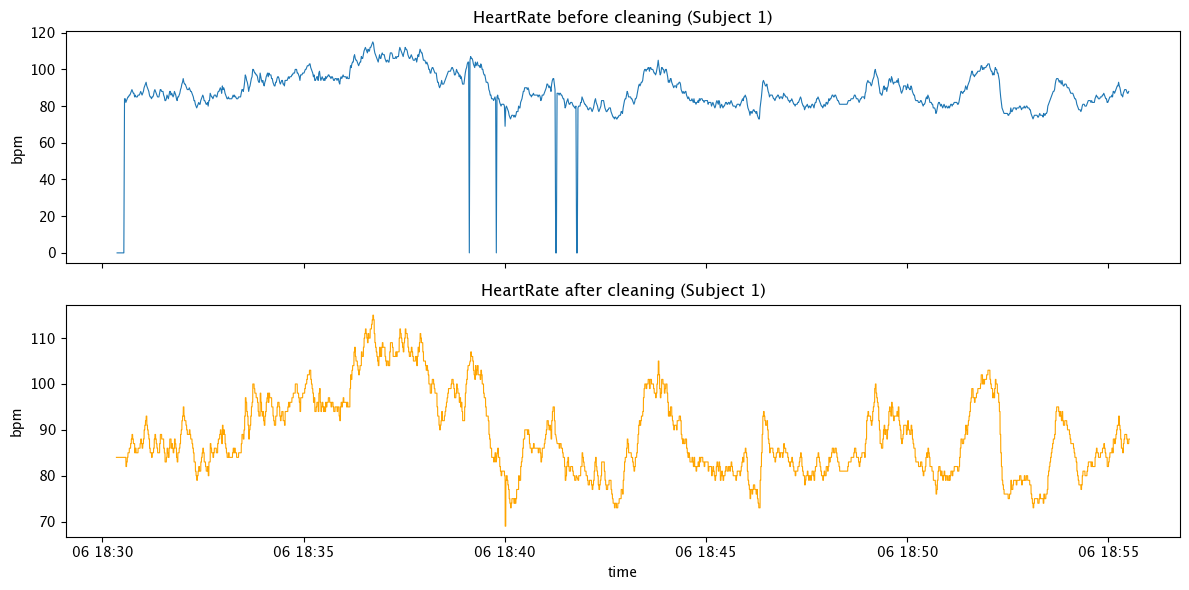

In [93]:
# Post-cleaning summary 
sensor_cols = [col for col in merged.columns if col not in ('time', 'subject')]

rows = []
for col in sensor_cols:
    s = merged[col]
    n_nan = int(s.isna().sum())
    rows.append({
        'column': col,
        'missing': n_nan,
        'missing_%': round(100 * n_nan / len(s), 2),
    })

post_summary = pd.DataFrame(rows).set_index('column')
print("Post-cleaning missing values:")
print(post_summary[post_summary['missing'] > 0] if post_summary['missing'].any() else "None")


subj1 = merged[merged['subject'] == 1].set_index('time')

with open('subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json') as f:
    records = json.load(f)
hr_raw = pd.DataFrame([r for r in records if r['sensor'] == 'HeartRate'])
hr_raw['time'] = pd.to_datetime(pd.to_numeric(hr_raw['time']), unit='ns')
hr_raw['bpm'] = pd.to_numeric(hr_raw['bpm'])
hr_raw = hr_raw.set_index('time').sort_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(hr_raw.index, hr_raw['bpm'], linewidth=0.8)
axes[0].set_title('HeartRate before cleaning (Subject 1)')
axes[0].set_ylabel('bpm')

axes[1].plot(subj1.index, subj1['HeartRate_bpm'], linewidth=0.8, color='orange')
axes[1].set_title('HeartRate after cleaning (Subject 1)')
axes[1].set_ylabel('bpm')
axes[1].set_xlabel('time')

plt.tight_layout()
plt.savefig('heartrate_before_after.png', dpi=150)
plt.show()

### Feature Engineering

In [94]:
# 1. Assign activity labels from recorded timestamps

activity_bounds = {
    1: [
        ('typing',  120, 507),
        ('writing', 533, 1268),
        ('drawing', 1290, 1485),
    ],
    2: [
        ('typing',  21,  464),
        ('writing', 468, 1095),
        ('drawing', 1111, 1309),
    ],
}

merged['label'] = None

for subj, bounds in activity_bounds.items():
    mask = merged['subject'] == subj
    t0 = merged.loc[mask, 'time'].min()
    elapsed = (merged.loc[mask, 'time'] - t0).dt.total_seconds()
    for activity, t_start, t_end in bounds:
        in_window = mask & (elapsed >= t_start) & (elapsed <= t_end)
        merged.loc[in_window, 'label'] = activity

print(merged['label'].value_counts(dropna=False))

label
writing    136202
typing      83002
None        44247
drawing     39302
Name: count, dtype: int64


In [95]:
# 2. Select accelerometer, gyroscope, and magnetometer columns

motion_cols = [col for col in merged.columns if any(
    s in col for s in ['WatchAccelerometer', 'WatchGyroscope', 'WatchMagnetometer']
)]

df = merged[['time', 'subject', 'label'] + motion_cols].copy()

print(f"Retained {len(motion_cols)} motion sensor columns:")
print(motion_cols)

Retained 9 motion sensor columns:
['WatchAccelerometer_y', 'WatchAccelerometer_z', 'WatchAccelerometer_x', 'WatchGyroscope_y', 'WatchGyroscope_z', 'WatchGyroscope_x', 'WatchMagnetometer_y', 'WatchMagnetometer_z', 'WatchMagnetometer_x']


In [96]:
# 3. Feature extraction over sliding windows

def extract_features(df, motion_cols, window, step, fs=100):
    freqs = np.fft.rfftfreq(window, d=1 / fs)
    feature_rows = []

    for subj in [1, 2]:
        subj_df = df[df['subject'] == subj].reset_index(drop=True)
        vals   = subj_df[motion_cols].values
        labels = subj_df['label'].values
        times  = subj_df['time'].values
        n      = len(subj_df)

        for t in range(window - 1, n, step):
            label = labels[t]
            if label is None:
                continue

            win = vals[t - window + 1 : t + 1]

            row = {'time': times[t], 'subject': subj, 'label': label}

            for j, col in enumerate(motion_cols):
                w = win[:, j]

                # time domain
                row[f'{col}_mean'] = w.mean()
                row[f'{col}_std']  = w.std()
                row[f'{col}_min']  = w.min()
                row[f'{col}_max']  = w.max()

                # frequency domain (exclude 0 Hz / DC component)
                amps  = np.abs(np.fft.rfft(w))
                amps_osc  = amps[1:]
                freqs_osc = freqs[1:]
                total_amp = amps_osc.sum()

                row[f'{col}_max_freq']  = freqs_osc[np.argmax(amps_osc)]
                row[f'{col}_freq_wavg'] = float((amps_osc * freqs_osc).sum() / total_amp) if total_amp > 0 else 0.0

                power = (amps ** 2) / window
                total = power.sum()
                if total > 0:
                    p = power / total
                    p = p[p > 0]
                    row[f'{col}_pse'] = float(-np.sum(p * np.log(p)))
                else:
                    row[f'{col}_pse'] = 0.0

            feature_rows.append(row)

    return pd.DataFrame(feature_rows).reset_index(drop=True)


WINDOW  = 200                          
OVERLAP = 0.5                          
STEP    = int(WINDOW * (1 - OVERLAP))

features = extract_features(df, motion_cols, WINDOW, STEP)

print(features['label'].value_counts())
print(features.shape)
features.head()

label
writing    1362
typing      830
drawing     393
Name: count, dtype: int64
(2585, 66)


,time,subject,label,WatchAccelerometer_y_mean,WatchAccelerometer_y_std,WatchAccelerometer_y_min,WatchAccelerometer_y_max,WatchAccelerometer_y_max_freq,WatchAccelerometer_y_freq_wavg,WatchAccelerometer_y_pse,...,WatchMagnetometer_z_max_freq,WatchMagnetometer_z_freq_wavg,WatchMagnetometer_z_pse,WatchMagnetometer_x_mean,WatchMagnetometer_x_std,WatchMagnetometer_x_min,WatchMagnetometer_x_max,WatchMagnetometer_x_max_freq,WatchMagnetometer_x_freq_wavg,WatchMagnetometer_x_pse
0,2026-06-06 18:32:21.870,1,typing,-0.331920,0.912653,-2.870648,2.444480,1.0,13.724647,2.995477,...,1.0,8.610103,0.058252,-15.296250,14.560097,-24.90,18.059999,0.5,7.399154,0.938401
1,2026-06-06 18:32:22.870,1,typing,-0.211384,0.820615,-2.870648,2.444480,1.5,14.323995,3.354050,...,0.5,9.674682,0.289779,-17.414672,6.375421,-24.90,-8.340000,0.5,8.150080,0.281898
2,2026-06-06 18:32:23.870,1,typing,-0.147339,0.686345,-1.929727,1.649605,0.5,16.097060,3.467516,...,0.5,10.021133,0.211752,-8.292600,5.226753,-15.78,4.320000,0.5,9.594557,0.684436
3,2026-06-06 18:32:24.870,1,typing,-0.087580,0.609054,-1.929727,1.649605,1.5,17.662114,3.657219,...,0.5,9.187454,0.081535,-2.627100,4.011640,-14.58,4.320000,0.5,11.345378,1.469259
4,2026-06-06 18:32:25.870,1,typing,-0.118633,0.501708,-1.489193,1.467646,1.5,18.053298,3.645593,...,1.5,8.443811,0.050621,-0.252600,2.007783,-3.54,4.200000,1.0,9.072096,1.700224


   window_s  instances  n_windows  mean_eta2   mean_F
0       1.0        100       5170      0.085  297.433
1       2.0        200       2585      0.096  175.939
2       5.0        500       1033      0.119   96.819

Most separable window: 5s (500 instances), mean eta2 = 0.119


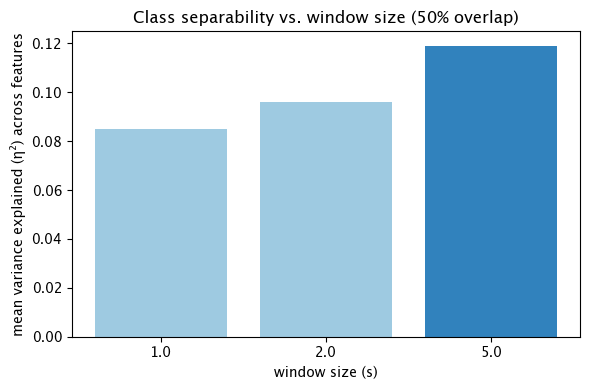

In [97]:
window_sizes = [100, 200, 500] 
k = 3                            

results = []
for win in window_sizes:
    step  = int(win * (1 - OVERLAP))   # same overlap as the main run
    feats = extract_features(df, motion_cols, win, step)
    X = feats.drop(columns=['time', 'subject', 'label'])
    y = feats['label']
    N = len(feats)

    F, _ = f_classif(X, y)

    eta2 = (F * (k - 1)) / (F * (k - 1) + (N - k))

    results.append({
        'window_s':  win / 100,
        'instances': win,
        'n_windows': N,
        'mean_eta2': np.nanmean(eta2),
        'mean_F':    np.nanmean(F),
    })

window_comparison = pd.DataFrame(results)
print(window_comparison.round(3))

best_row = window_comparison.loc[window_comparison['mean_eta2'].idxmax()]
print(f"\nMost separable window: {best_row['window_s']:.0f}s "
      f"({best_row['instances']:.0f} instances), mean eta2 = {best_row['mean_eta2']:.3f}")

best = window_comparison['mean_eta2'].max()
colors = ['#3182bd' if v == best else '#9ecae1' for v in window_comparison['mean_eta2']]

plt.figure(figsize=(6, 4))
plt.bar(window_comparison['window_s'].astype(str), window_comparison['mean_eta2'], color=colors)
plt.xlabel('window size (s)')
plt.ylabel('mean variance explained (η²) across features')
plt.title(f'Class separability vs. window size ({OVERLAP:.0%} overlap)')
plt.tight_layout()
plt.savefig('window_size_comparison.png', dpi=150)
plt.show()

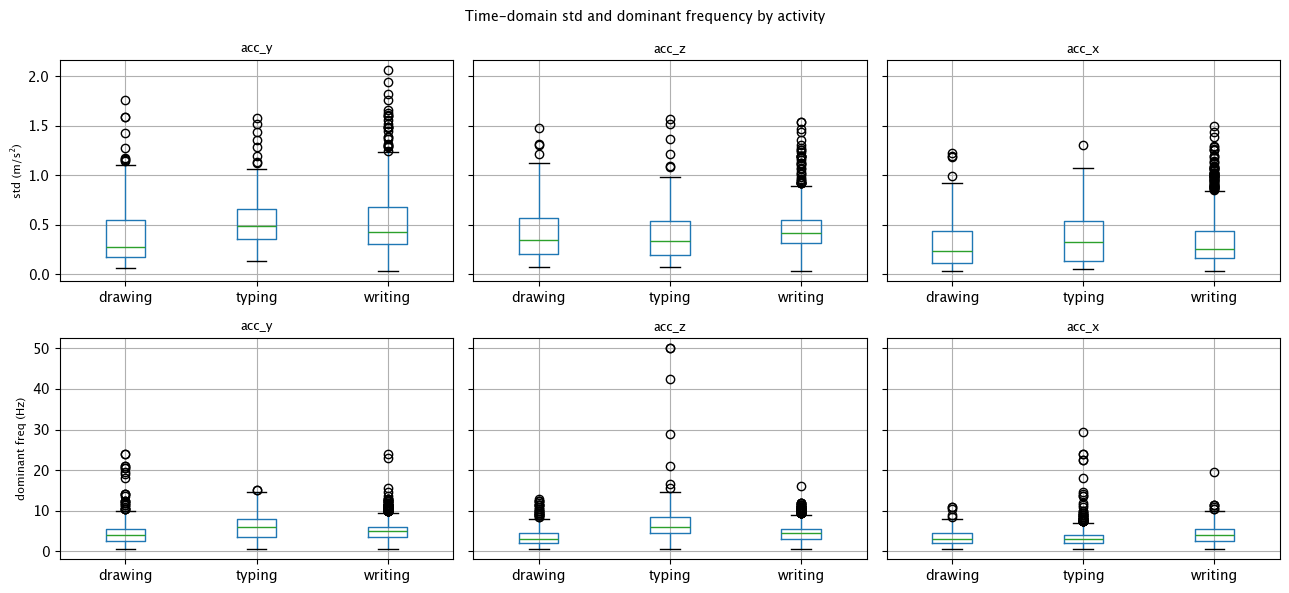

label                          drawing  typing  writing
WatchAccelerometer_y_std         0.387   0.518    0.505
WatchAccelerometer_y_max_freq    4.747   5.835    5.061
WatchAccelerometer_y_pse         2.679   3.516    3.065
WatchAccelerometer_z_std         0.421   0.375    0.448
WatchAccelerometer_z_max_freq    3.615   6.686    4.580
WatchAccelerometer_z_pse         2.732   3.642    3.141
WatchAccelerometer_x_std         0.307   0.357    0.333
WatchAccelerometer_x_max_freq    3.307   3.361    3.935
WatchAccelerometer_x_pse         2.742   3.084    2.860


In [98]:
# 4. Analyse feature usefulness

acc_cols = [c for c in motion_cols if 'Accelerometer' in c]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey='row')

for i, col in enumerate(acc_cols):
    for ax, feat, ylabel in zip(
        [axes[0, i], axes[1, i]],
        [f'{col}_std', f'{col}_max_freq'],
        ['std (m/s²)', 'dominant freq (Hz)'],
    ):
        features.boxplot(column=feat, by='label', ax=ax)
        ax.set_title(col.replace('WatchAccelerometer_', 'acc_'), fontsize=9)
        ax.set_xlabel('')
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=8)

plt.suptitle('Time-domain std and dominant frequency by activity', fontsize=10)
plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150)
plt.show()

# Per-label mean table for the report
key_cols = [f'{c}{s}' for c in acc_cols for s in ['_std', '_max_freq', '_pse']]
print(features.groupby('label')[key_cols].mean().round(3).T)